In [1115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [1116]:
# load the data
data = pd.read_csv("malaria_control_africa.csv")
data.head()

,iso3,country,year,malaria_incidence_per_1000_at_risk,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,population_total,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,urban_population_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
0,AGO,Angola,2000,326.539432,13.159986,49.492935,563.733796,16194869.0,62.331443,12.990189,185.0,46.501,37.842237,50.507065,0.980978,NaN,6.639
1,AGO,Angola,2001,330.804593,29.260958,48.277521,533.586202,16747208.0,61.886219,13.433230,176.3,47.032,38.338816,51.722479,1.806842,NaN,6.601
2,AGO,Angola,2002,315.697197,29.370771,47.107377,999.065856,17327699.0,61.440995,13.898852,166.4,47.874,38.835392,52.892623,1.155481,NaN,6.567
3,AGO,Angola,2003,319.287503,35.220695,45.995645,1133.663320,17943712.0,60.995770,14.392967,155.5,50.218,40.396516,54.004355,1.283358,NaN,6.533
4,AGO,Angola,2004,312.646868,50.233109,44.955472,1451.471179,18600423.0,60.550546,14.919726,143.7,51.123,41.977237,55.044528,1.471358,NaN,6.499


In [1117]:
# shape of data
nbrs_rows, nbr_columns = data.shape
print("Number of rows:", nbrs_rows)
print("Number of columns:", nbr_columns)

Number of rows: 1226
Number of columns: 17


In [1118]:
# columns name
data.columns

Index(['iso3', 'country', 'year', 'malaria_incidence_per_1000_at_risk',
       'health_expenditure_per_capita_usd', 'rural_population_pct',
       'gdp_per_capita_usd', 'population_total', 'forest_area_pct',
       'population_density', 'under5_mortality_per_1000',
       'life_expectancy_years', 'basic_water_access_pct',
       'urban_population_pct', 'govt_health_exp_pct_gdp',
       'primary_completion_rate_pct', 'fertility_rate_births_per_woman'],
      dtype='object')

In [1119]:
# basic datasets description
data.describe()

,year,malaria_incidence_per_1000_at_risk,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,population_total,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,urban_population_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
count,1226.000000,1226.000000,1088.000000,1128.000000,1102.000000,1.128000e+03,1104.000000,1104.000000,1128.000000,1128.000000,1105.000000,1128.000000,1088.000000,697.000000,1128.000000
mean,2012.007341,202.196120,86.758373,58.833389,1787.217101,2.227089e+07,29.940718,82.354133,88.461791,59.172021,62.830858,41.166611,1.526331,66.037295,4.843926
std,7.215682,159.520600,111.434801,17.220185,2186.402576,3.144274e+07,24.552587,99.281947,46.899931,6.881238,16.771684,17.220185,1.121366,20.867578,1.253761
min,2000.000000,0.000000,4.175786,8.775664,109.593814,1.440180e+05,0.045186,2.208999,12.100000,14.665000,18.759061,8.043814,0.062210,15.692990,1.420000
25%,2006.000000,45.052028,25.556381,46.374522,519.891498,3.123406e+06,10.889408,19.745724,53.675000,54.753000,50.676168,28.236223,0.747266,53.304710,4.045250
50%,2012.000000,213.708044,46.541132,60.470306,952.327529,1.232498e+07,24.253106,48.372923,79.900000,59.474000,61.944953,39.529694,1.222135,64.667885,4.933500
75%,2018.000000,339.645518,82.955479,71.763777,2068.148606,2.740569e+07,45.408122,97.119312,117.000000,63.428000,75.610569,53.625478,1.867058,83.540373,5.683500
max,2024.000000,711.438315,686.872437,91.956186,18210.555297,2.231509e+08,93.247059,634.118177,489.300000,76.129000,99.853747,91.224336,6.518854,114.697441,7.829000


In [1120]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1226 entries, 0 to 1225
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso3                                1226 non-null   object 
 1   country                             1226 non-null   object 
 2   year                                1226 non-null   int64  
 3   malaria_incidence_per_1000_at_risk  1226 non-null   float64
 4   health_expenditure_per_capita_usd   1088 non-null   float64
 5   rural_population_pct                1128 non-null   float64
 6   gdp_per_capita_usd                  1102 non-null   float64
 7   population_total                    1128 non-null   float64
 8   forest_area_pct                     1104 non-null   float64
 9   population_density                  1104 non-null   float64
 10  under5_mortality_per_1000           1128 non-null   float64
 11  life_expectancy_years               1128 no

In [1121]:
# check different values inside country column
country_count = data["country"].value_counts()
country_count

country
Angola                      25
Burundi                     25
Benin                       25
Burkina Faso                25
Botswana                    25
Central African Republic    25
Cote d'Ivoire               25
Cameroon                    25
Congo, Dem. Rep.            25
Congo, Rep.                 25
Comoros                     25
Cabo Verde                  25
Djibouti                    25
Algeria                     25
Egypt, Arab Rep.            25
Eritrea                     25
Ethiopia                    25
Gabon                       25
Ghana                       25
Guinea                      25
Gambia, The                 25
Guinea-Bissau               25
Equatorial Guinea           25
Kenya                       25
Liberia                     25
Morocco                     25
Madagascar                  25
Mali                        25
Mozambique                  25
Mauritania                  25
Malawi                      25
Namibia                     25


In [1122]:
# check number of missing values
nan_values = data.isna().sum()
missing_values_table = pd.DataFrame({
    "Missing Values": nan_values,
    "Ratio Missing Values (%)": (nan_values/len(data))*100
})
missing_values_table = (
    missing_values_table
    .sort_values(by="Ratio Missing Values (%)", ascending=False)
    .round({"Ratio Missing Values (%)":2})
    .reset_index()
    .rename(columns={"index":"Column Name"})
)
missing_values_table

,Column Name,Missing Values,Ratio Missing Values (%)
0,primary_completion_rate_pct,529,43.15
1,govt_health_exp_pct_gdp,138,11.26
2,health_expenditure_per_capita_usd,138,11.26
3,gdp_per_capita_usd,124,10.11
4,forest_area_pct,122,9.95
5,population_density,122,9.95
6,basic_water_access_pct,121,9.87
7,life_expectancy_years,98,7.99
8,rural_population_pct,98,7.99
9,fertility_rate_births_per_woman,98,7.99


### Build heatmap to see how features relate with the target value (malaria_incidence_per_1000_at_rist)

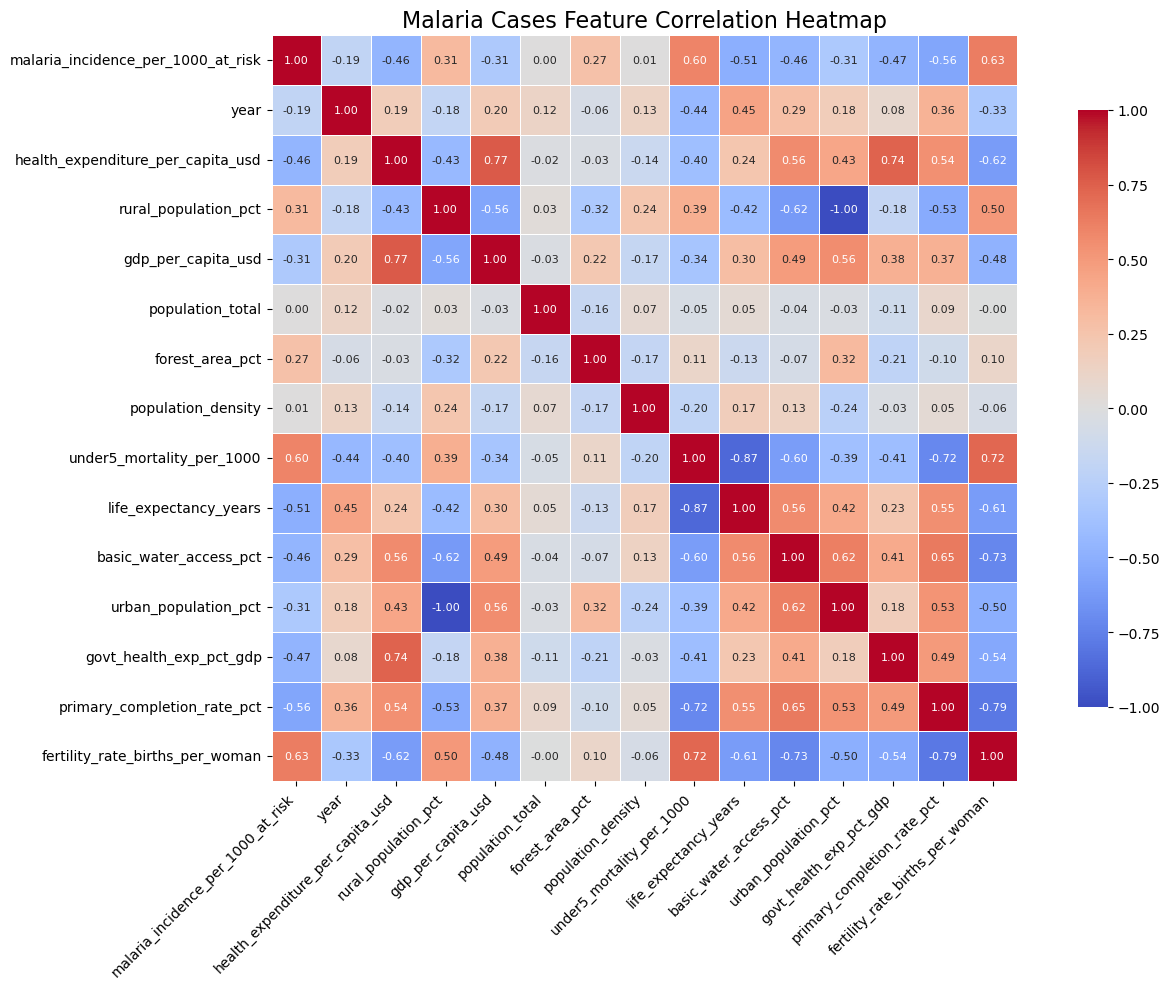

In [1123]:
features = [
    "malaria_incidence_per_1000_at_risk",
    "year",
    "health_expenditure_per_capita_usd",
    "rural_population_pct",
    "gdp_per_capita_usd",
    "population_total",
    "forest_area_pct",
    "population_density",
    "under5_mortality_per_1000",
    "life_expectancy_years",
    "basic_water_access_pct",
    "urban_population_pct",
    "govt_health_exp_pct_gdp",
    "primary_completion_rate_pct",
    "fertility_rate_births_per_woman",
]

corr = data[features].corr()

# Plot
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Malaria Cases Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [1124]:
# handling missing values with the mean of each column
clean_data = data.copy()

numeric_cols = clean_data.select_dtypes(include=np.number).columns

clean_data[numeric_cols] = clean_data[numeric_cols].fillna(
    clean_data[numeric_cols].mean()
)
clean_data.isna().sum()

iso3                                  0
country                               0
year                                  0
malaria_incidence_per_1000_at_risk    0
health_expenditure_per_capita_usd     0
rural_population_pct                  0
gdp_per_capita_usd                    0
population_total                      0
forest_area_pct                       0
population_density                    0
under5_mortality_per_1000             0
life_expectancy_years                 0
basic_water_access_pct                0
urban_population_pct                  0
govt_health_exp_pct_gdp               0
primary_completion_rate_pct           0
fertility_rate_births_per_woman       0
dtype: int64

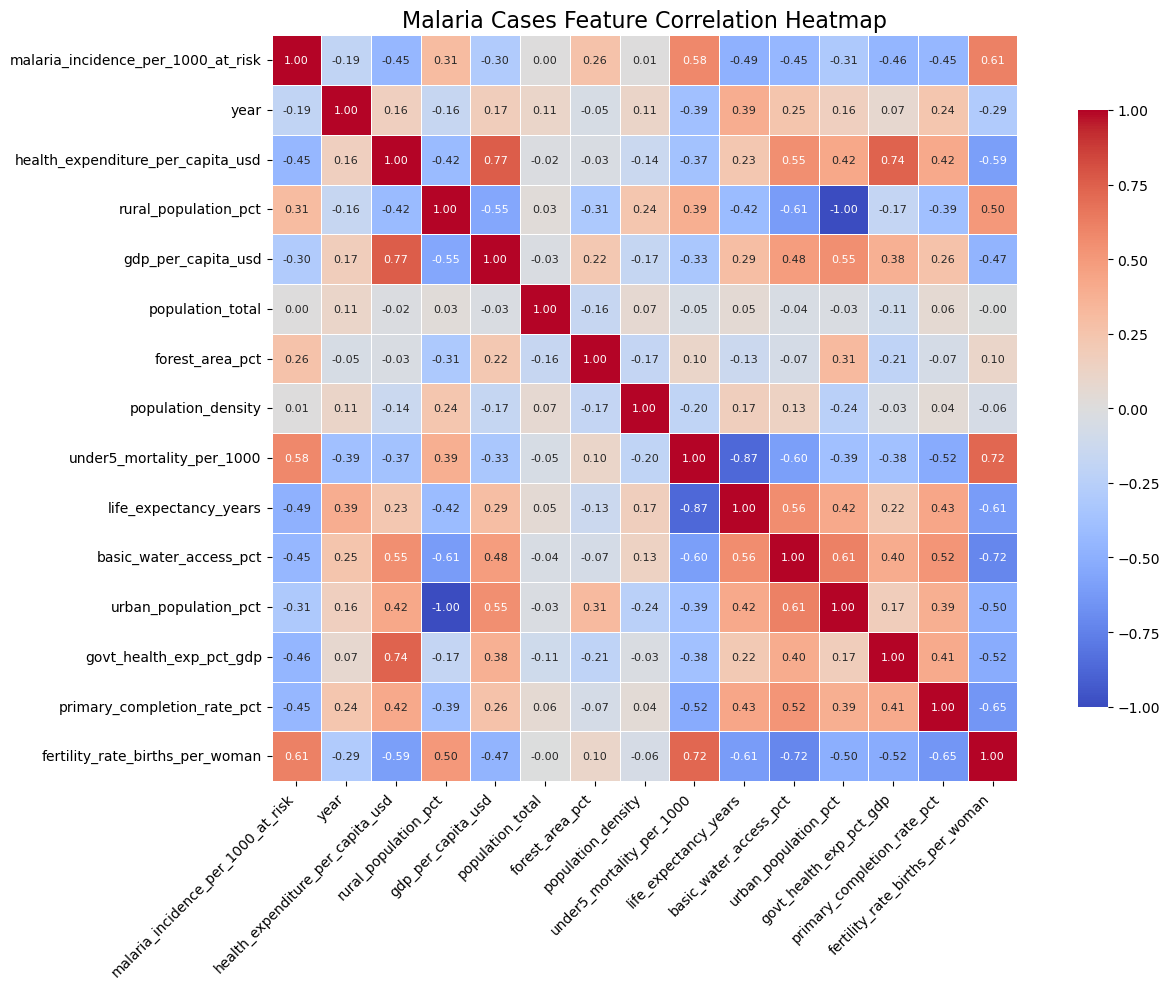

In [1125]:
# compute heatmap after cleaning NAN values
features = [
    "malaria_incidence_per_1000_at_risk",
    "year",
    "health_expenditure_per_capita_usd",
    "rural_population_pct",
    "gdp_per_capita_usd",
    "population_total",
    "forest_area_pct",
    "population_density",
    "under5_mortality_per_1000",
    "life_expectancy_years",
    "basic_water_access_pct",
    "urban_population_pct",
    "govt_health_exp_pct_gdp",
    "primary_completion_rate_pct",
    "fertility_rate_births_per_woman",
]

corr = clean_data[features].corr()

# Plot
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Malaria Cases Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [1126]:
col = "primary_completion_rate_pct"
data_sorted = data.sort_values(["country", "year"])

# global mean
global_mean_fill = data_sorted[col].fillna(data_sorted[col].mean())

# Approach B: within-country linear interpolation
interpolated_fill = (
    data_sorted.groupby("country")[col]
    .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
)
interpolated_fill.index = data_sorted.index

print("Missing before:", data_sorted[col].isna().sum())
print("Missing after interpolation:", interpolated_fill.isna().sum())


Missing before: 529
Missing after interpolation: 50


In [1127]:
print("Standard deviation, original data only: ", round(data_sorted[col].std(), 2))
print("Standard deviation, after filling wih global mean: ", round(global_mean_fill.std(), 2))
print("Standard deviation, after interpolating: ", round(interpolated_fill.std(), 2))

Standard deviation, original data only:  20.87
Standard deviation, after filling wih global mean:  15.73
Standard deviation, after interpolating:  20.79


In [1128]:
target = "malaria_incidence_per_1000_at_risk"

real_only_corr = data_sorted[[target, col]].corr().iloc[0, 1]

df_mean = data_sorted.copy()
df_mean[col] = global_mean_fill

df_interp = data_sorted.copy()
df_interp[col] = interpolated_fill

print("Real data only:    ", round(data_sorted[[target, col]].corr().iloc[0, 1], 3))
print("Global mean fill:  ", round(df_mean[[target, col]].corr().iloc[0, 1], 3))
print("Interpolated fill: ", round(df_interp[[target, col]].corr().iloc[0, 1], 3))


Real data only:     -0.561
Global mean fill:   -0.45
Interpolated fill:  -0.549


In [1129]:
# missing values by country
missing_by_country = data.groupby("country").apply(lambda df: df.isna().sum())

missing_by_country

/tmp/ipykernel_184240/2802256112.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_country = data.groupby("country").apply(lambda df: df.isna().sum())


,iso3,country,year,malaria_incidence_per_1000_at_risk,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,population_total,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,urban_population_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
country,,,,,,,,,,,,,,,,,
Algeria,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,2,2
Angola,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,20,2
Benin,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,8,2
Botswana,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,12,2
Burkina Faso,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,3,2
Burundi,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,5,2
Cabo Verde,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,2,2
Cameroon,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,7,2
Central African Republic,0,0,0,0,2,2,2,2,2,2,2,2,2,2,2,16,2


### The missing data in primary_completion_rate_pct column after interpolation comes from two countries Djibouti and Somalia, Fed. Rep. with No values since 2000 to 2025. In fact, there is no available data reported for those countries. Thus, interpolation failed. Because of the complete lack of information, the two countries will not be considered in our model. Fix and apply the same interpolation pattern in all the columns with missing values

In [1130]:
other_cols = [
    "health_expenditure_per_capita_usd", "govt_health_exp_pct_gdp", "gdp_per_capita_usd",
    "forest_area_pct", "population_density", "basic_water_access_pct", "life_expectancy_years",
    "rural_population_pct", "fertility_rate_births_per_woman", "under5_mortality_per_1000",
    "urban_population_pct", "population_total",
]

clean_data_interp = data_sorted.copy()

for columns in other_cols:
    clean_data_interp[columns] = (
        data_sorted.groupby("country")[columns]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .values
    )
clean_data_interp

,iso3,country,year,malaria_incidence_per_1000_at_risk,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,population_total,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,urban_population_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
325,DZA,Algeria,2000,0.018730,61.857853,40.147876,1772.928691,30903893.0,0.662961,12.975343,41.7,70.576,88.993808,59.852124,2.313520,81.979156,2.590
326,DZA,Algeria,2001,0.003260,67.058594,39.382283,1896.300209,31331221.0,0.677194,13.154761,40.2,71.025,89.169802,60.617717,2.695605,89.100311,2.519
327,DZA,Algeria,2002,0.005362,66.681633,38.618734,1937.464114,31750835.0,0.691427,13.330941,38.6,71.644,89.343640,61.381266,2.590863,91.904259,2.429
328,DZA,Algeria,2003,0.002645,75.951309,37.857209,2283.772993,32175818.0,0.705661,13.509375,37.0,71.906,89.515109,62.142791,2.550614,94.512001,2.451
329,DZA,Algeria,2004,0.001044,92.687630,37.097687,2816.993850,32628286.0,0.719894,13.699348,35.4,72.536,89.684221,62.902313,2.347748,96.502480,2.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221,ZWE,Zimbabwe,2020,94.296872,51.142506,62.990233,2059.637040,15526888.0,45.093912,40.136714,61.7,61.530,67.166424,37.009767,0.652689,88.343367,3.754
1222,ZWE,Zimbabwe,2021,27.537495,60.898743,62.130794,2613.616741,15797210.0,44.974822,40.835492,62.4,60.135,67.162605,37.869206,0.879811,83.033886,3.765
1223,ZWE,Zimbabwe,2022,28.901366,68.907280,61.294479,2536.401971,16069056.0,44.855732,41.538209,64.0,62.360,67.168908,38.705521,1.018298,83.198409,3.767
1224,ZWE,Zimbabwe,2023,49.396046,68.907280,61.294479,2536.401971,16069056.0,44.855732,41.538209,64.0,62.360,67.168908,38.705521,1.018298,NaN,3.767


In [1131]:
# drop Djibouti and Somalia, Fed. Rep. with the reason provided above
clean_data_interp["primary_completion_rate_pct"] = interpolated_fill.values
clean_data_interp = clean_data_interp[~clean_data_interp["country"].isin(["Djibouti", "Somalia, Fed. Rep."])]

clean_data_interp.isna().sum()


iso3                                  0
country                               0
year                                  0
malaria_incidence_per_1000_at_risk    0
health_expenditure_per_capita_usd     0
rural_population_pct                  0
gdp_per_capita_usd                    0
population_total                      0
forest_area_pct                       0
population_density                    0
under5_mortality_per_1000             0
life_expectancy_years                 0
basic_water_access_pct                0
urban_population_pct                  0
govt_health_exp_pct_gdp               0
primary_completion_rate_pct           0
fertility_rate_births_per_woman       0
dtype: int64

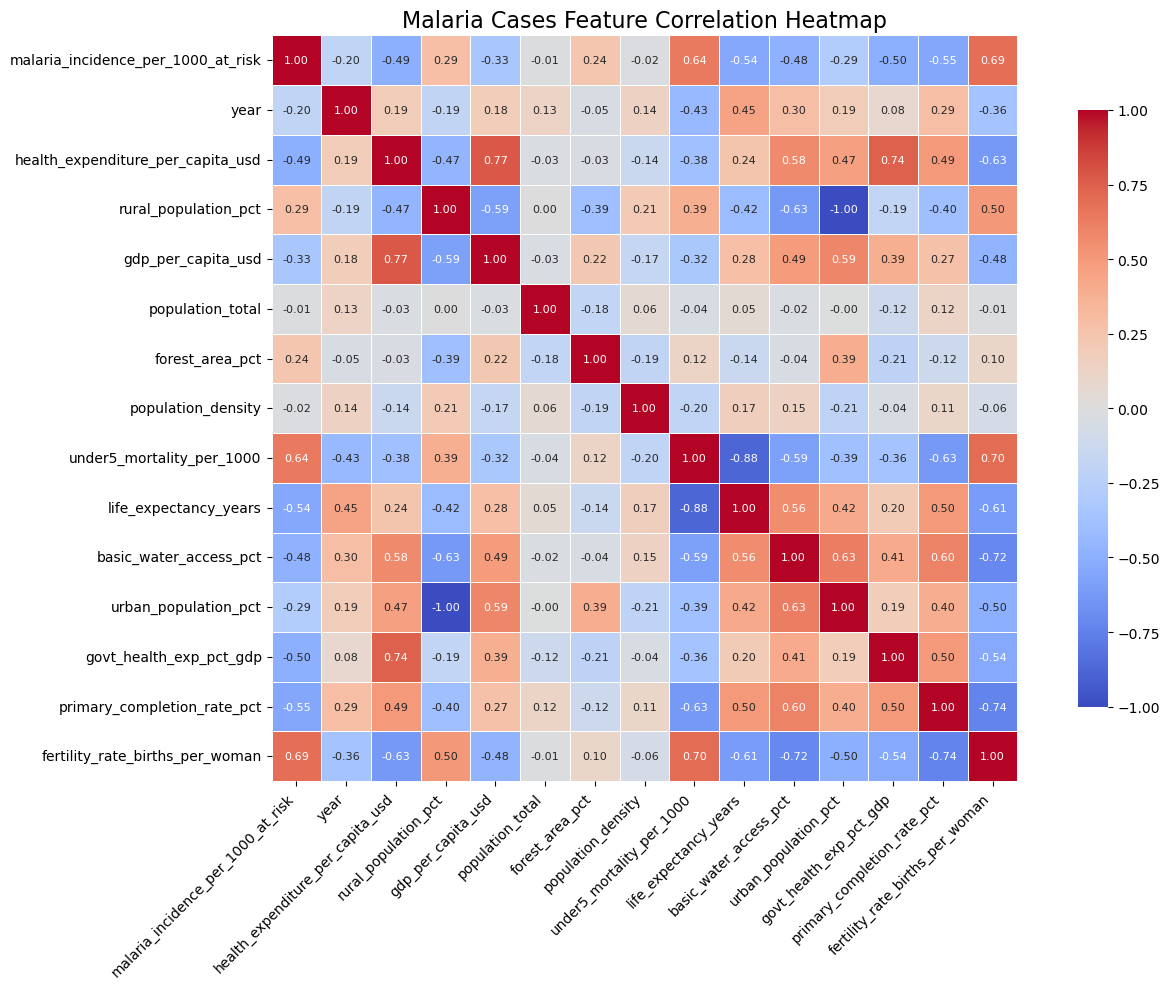

In [1132]:
# compute heatmap after interpolating NAN values and removing Djibouti and Somalia, Fed. Rep
features = [
    "malaria_incidence_per_1000_at_risk",
    "year",
    "health_expenditure_per_capita_usd",
    "rural_population_pct",
    "gdp_per_capita_usd",
    "population_total",
    "forest_area_pct",
    "population_density",
    "under5_mortality_per_1000",
    "life_expectancy_years",
    "basic_water_access_pct",
    "urban_population_pct",
    "govt_health_exp_pct_gdp",
    "primary_completion_rate_pct",
    "fertility_rate_births_per_woman",
]

corr = clean_data_interp[features].corr()

# Plot
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Malaria Cases Feature Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

### For my model, country and ISO3 will be removed. Also, rural_population_pct and urban_population_pct have a collinearity of -1. This is because the rural_population_pct is just the probability complement of urban_population_pct. The two features carry the same information. However, for epidemiological reasons, more specifically, I want to analyze how the number of malaria cases increase or decrease when there is a high concentration of the population in rural area, I will keep rural_population_pct and drop urban_population_pct.

In [1133]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

feature_cols = [
    "year", "health_expenditure_per_capita_usd", "gdp_per_capita_usd", "population_total",
    "forest_area_pct", "population_density", "under5_mortality_per_1000", "life_expectancy_years",
    "basic_water_access_pct", "rural_population_pct", "govt_health_exp_pct_gdp",
    "primary_completion_rate_pct", "fertility_rate_births_per_woman",
] 

X = add_constant(clean_data_interp[feature_cols])

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["Variance Inflation Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif["feature"] != "const"].sort_values("Variance Inflation Factor", ascending=False)
vif


,feature,Variance Inflation Factor
2,health_expenditure_per_capita_usd,7.402144
7,under5_mortality_per_1000,6.673141
8,life_expectancy_years,6.241699
3,gdp_per_capita_usd,4.062068
13,fertility_rate_births_per_woman,3.871221
9,basic_water_access_pct,3.274758
10,rural_population_pct,3.271484
11,govt_health_exp_pct_gdp,3.245379
12,primary_completion_rate_pct,2.803545
5,forest_area_pct,1.812715


### Moreover, although population_total and population_densisty all have near zero collinearity with our target, population_density will be kept while population_total will be removed. In fact, malaria spreads through mosquito bites, so transmission depends on how much contact happens between people and mosquito breeding sites, and between infected and uninfected people. That contact rate is driven by how packed together people and breeding sites are, not by how many people exist in the country overall. For instance, two countries can have the same total population but very different transmission dynamics if one is spread thin across a huge area and the other is concentrated. In that case, density is a proxy for exposure/contact rate; raw population count is not. Therefore, population_density will be kept in our model and population_total will be rmeoved.

In [1134]:
columns_to_drop = ["iso3", "country", "urban_population_pct", "population_total"]
model_data = clean_data_interp.drop(columns=columns_to_drop, axis=1)
model_data.head()

,year,malaria_incidence_per_1000_at_risk,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
325,2000,0.018730,61.857853,40.147876,1772.928691,0.662961,12.975343,41.7,70.576,88.993808,2.313520,81.979156,2.590
326,2001,0.003260,67.058594,39.382283,1896.300209,0.677194,13.154761,40.2,71.025,89.169802,2.695605,89.100311,2.519
327,2002,0.005362,66.681633,38.618734,1937.464114,0.691427,13.330941,38.6,71.644,89.343640,2.590863,91.904259,2.429
328,2003,0.002645,75.951309,37.857209,2283.772993,0.705661,13.509375,37.0,71.906,89.515109,2.550614,94.512001,2.451
329,2004,0.001044,92.687630,37.097687,2816.993850,0.719894,13.699348,35.4,72.536,89.684221,2.347748,96.502480,2.500


In [1135]:
model_data.shape

(1176, 13)

In [1136]:
model_data.columns

Index(['year', 'malaria_incidence_per_1000_at_risk',
       'health_expenditure_per_capita_usd', 'rural_population_pct',
       'gdp_per_capita_usd', 'forest_area_pct', 'population_density',
       'under5_mortality_per_1000', 'life_expectancy_years',
       'basic_water_access_pct', 'govt_health_exp_pct_gdp',
       'primary_completion_rate_pct', 'fertility_rate_births_per_woman'],
      dtype='object')

In [1137]:
# choosing features and target
features_columns = ['health_expenditure_per_capita_usd', 'rural_population_pct',
       'gdp_per_capita_usd', 'forest_area_pct', 'population_density',
       'under5_mortality_per_1000', 'life_expectancy_years',
       'basic_water_access_pct', 'govt_health_exp_pct_gdp',
       'primary_completion_rate_pct', 'fertility_rate_births_per_woman'
       ]
target_column = "malaria_incidence_per_1000_at_risk"

In [1138]:
# split data per year (2000-2018 for training and 2019 above for testing)
train_data = model_data[model_data["year"] <= 2018]
test_data = model_data[model_data["year"] > 2018]

In [1139]:
print(f"Train dataset shape: {train_data.shape}")
print(f"Test dataset shape: {test_data.shape}")

Train dataset shape: (893, 13)
Test dataset shape: (283, 13)


In [1140]:
# training and test data (exclude year)
X_train = train_data[features_columns]
X_test = test_data[features_columns]
Y_train = train_data[target_column]
Y_test = test_data[target_column]

In [1141]:
X_test.head()

,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
344,242.070496,27.517544,4468.453419,0.814111,18.177696,23.3,75.682,91.999802,3.275980,97.539467,2.997
345,211.072403,26.945887,3743.541952,0.818309,18.491561,22.9,73.257,92.137824,3.311859,100.705688,2.940
346,208.939117,26.380078,4160.559267,0.822088,18.793445,22.6,75.208,92.273232,2.873339,98.357680,2.870
347,180.334549,25.820414,4960.303343,0.826287,19.094187,22.3,76.129,92.323673,1.716631,93.929104,2.817
348,180.334549,25.820414,4960.303343,0.826287,19.094187,22.3,76.129,92.323673,1.716631,93.929104,2.817


In [1142]:
# save train and test dataset
train_data[features_columns + [target_column]].to_csv("malaria_control_africa_train_data.csv", index=False)
test_data[features_columns + [target_column]].to_csv("malaria_control_africa_test_data.csv", index=False)

In [1143]:
# standardizing data
from sklearn.preprocessing import StandardScaler

st_scaler = StandardScaler()
X_train_scaled = st_scaler.fit_transform(X_train)
X_test_scaled = st_scaler.transform(X_test)
X_train_scaled, X_test_scaled

(array([[-0.19170952, -1.21343806,  0.01686227, ...,  0.73797794,
          0.88080817, -1.96850348],
        [-0.14383595, -1.25927707,  0.07199624, ...,  1.09152356,
          1.22365517, -2.02742898],
        [-0.14730593, -1.30499365,  0.09039214, ...,  0.99460523,
          1.35865083, -2.10212328],
        ...,
        [ 0.17926925,  0.32964112, -0.1461598 , ..., -0.13297988,
          1.21487107, -0.94104188],
        [ 0.08457499,  0.29242658,  0.76430149, ...,  0.03239811,
          1.16740166, -0.99083808],
        [ 0.29533742,  0.25009227,  0.23940049, ...,  0.07337363,
          1.16441523, -1.01075656]]),
 array([[ 1.46717391, -1.96966451,  1.22147569, ...,  1.62854753,
          1.62995716, -1.63071925],
        [ 1.18183198, -2.00389178,  0.89751722, ...,  1.66174645,
          1.78239443, -1.67802564],
        [ 1.16219478, -2.03776894,  1.08387969, ...,  1.2559816 ,
          1.66934991, -1.73612121],
        ...,
        [-0.12681852,  0.05269022,  0.35805378, ..., -

In [1144]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_columns, index=X_test.index)
X_train_scaled.describe()

,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
count,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02,8.930000e+02
mean,1.312873e-16,4.933219e-16,-4.774083e-17,5.967604e-17,5.569764e-17,2.148337e-16,2.227906e-16,9.548167e-17,1.352657e-16,-5.569764e-17,-5.529980e-16
std,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00,1.000560e+00
min,-7.226813e-01,-2.985816e+00,-7.264719e-01,-1.255025e+00,-8.207623e-01,-1.705046e+00,-6.534034e+00,-2.552817e+00,-1.345170e+00,-2.310530e+00,-2.620834e+00
25%,-5.443202e-01,-7.032103e-01,-5.533659e-01,-8.133969e-01,-6.552960e-01,-7.593498e-01,-6.702609e-01,-7.188972e-01,-7.156852e-01,-6.291348e-01,-5.891487e-01
50%,-3.810206e-01,5.902464e-02,-3.707668e-01,-2.131728e-01,-3.409022e-01,-1.362510e-01,1.552216e-02,-9.170359e-02,-2.634685e-01,-4.726856e-02,1.181864e-01
75%,-1.367479e-02,7.866634e-01,3.811549e-02,6.122713e-01,1.630842e-01,6.194219e-01,6.264003e-01,7.054309e-01,3.246236e-01,7.676226e-01,6.258786e-01
max,5.561640e+00,1.888524e+00,7.362737e+00,2.538056e+00,4.605625e+00,8.772735e+00,2.551547e+00,2.273469e+00,4.206282e+00,2.456025e+00,2.379535e+00


In [1145]:
X_test_scaled.describe()

,health_expenditure_per_capita_usd,rural_population_pct,gdp_per_capita_usd,forest_area_pct,population_density,under5_mortality_per_1000,life_expectancy_years,basic_water_access_pct,govt_health_exp_pct_gdp,primary_completion_rate_pct,fertility_rate_births_per_woman
count,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000,283.000000
mean,0.244692,-0.333671,0.189275,-0.077642,0.291734,-0.629961,0.732712,0.504320,0.190975,0.402779,-0.677878
std,1.124655,1.051078,0.891756,0.958156,1.359055,1.059585,1.039911,0.925175,1.165152,0.940233,0.846347
min,-0.618432,-3.091813,-0.670737,-1.255025,-0.809884,-1.771333,-5.914353,-1.568225,-1.093921,-1.686036,-2.939529
25%,-0.413507,-1.184185,-0.403178,-0.813397,-0.566220,-1.143815,0.376618,-0.058227,-0.597725,-0.183194,-1.004947
50%,-0.200538,-0.220914,-0.209490,-0.325458,-0.152268,-0.900762,0.753381,0.474756,-0.193250,0.312013,-0.657204
75%,0.195709,0.499252,0.395788,0.568651,0.419836,-0.279873,1.253990,1.375080,0.648932,1.197909,-0.272113
max,4.704706,1.403872,3.326014,2.461534,5.982876,7.343144,2.637195,2.325223,4.629194,2.017014,1.307257


In [1146]:
import joblib
joblib.dump(st_scaler, "scaler.pkl")

['scaler.pkl']

In [1147]:
linear_model = LinearRegression()
linear_model

LinearRegression()

In [1148]:
linear_model.fit(X_train_scaled, Y_train)

LinearRegression()

In [1149]:
Y_train_pred = linear_model.predict(X_train_scaled)
Y_test_pred = linear_model.predict(X_test_scaled)

In [1150]:
train_rmse = root_mean_squared_error(Y_train, Y_train_pred)
test_rmse = root_mean_squared_error(Y_test, Y_test_pred)
r2_train_score = r2_score(Y_train, Y_train_pred) * 100
r2_test_score = r2_score(Y_test, Y_test_pred) * 100
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R² in %:", round(r2_train_score, 3))
print("Test R² in %:", round(r2_test_score, 3))

Train RMSE: 106.16801399707701
Test RMSE: 100.88778057776922
Train R² in %: 59.151
Test R² in %: 38.777


In [1151]:
row = X_test_scaled.iloc[[0]]
actual = Y_test.iloc[0]
predicted = linear_model.predict(row)[0]

print("Actual malaria incidence:   ", round(actual, 3))
print("Predicted malaria incidence:", round(predicted, 3))
print("Difference:                 ", round(predicted - actual, 3))


Actual malaria incidence:    0.0
Predicted malaria incidence: -17.577
Difference:                  -17.577
